<a href="https://colab.research.google.com/github/rikesh28/Credit_Card_Fraud_Detection/blob/main/notebooks/3)%20preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
transaction_data = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Raw Data/train_transaction.csv.zip')
identity_data = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Raw Data/train_identity.csv.zip')

In [ ]:
# Merging data
df = transaction_data.merge(identity_data, on = 'TransactionID', how = 'left')
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


Features with missing values: 414

 =========TOP 20 FEATURES WITH MISSING DATA=========

      column  missing_count  missing_percentage
id_24  id_24         585793               99.20
id_21  id_21         585381               99.13
id_07  id_07         585385               99.13
id_25  id_25         585408               99.13
id_26  id_26         585377               99.13
id_08  id_08         585385               99.13
id_27  id_27         585371               99.12
id_23  id_23         585371               99.12
id_22  id_22         585371               99.12
dist2  dist2         552913               93.63
D7        D7         551623               93.41
id_18  id_18         545427               92.36
D13      D13         528588               89.51
D14      D14         528353               89.47
D12      D12         525823               89.04
id_04  id_04         524216               88.77
id_03  id_03         524216               88.77
D6        D6         517353               87.61

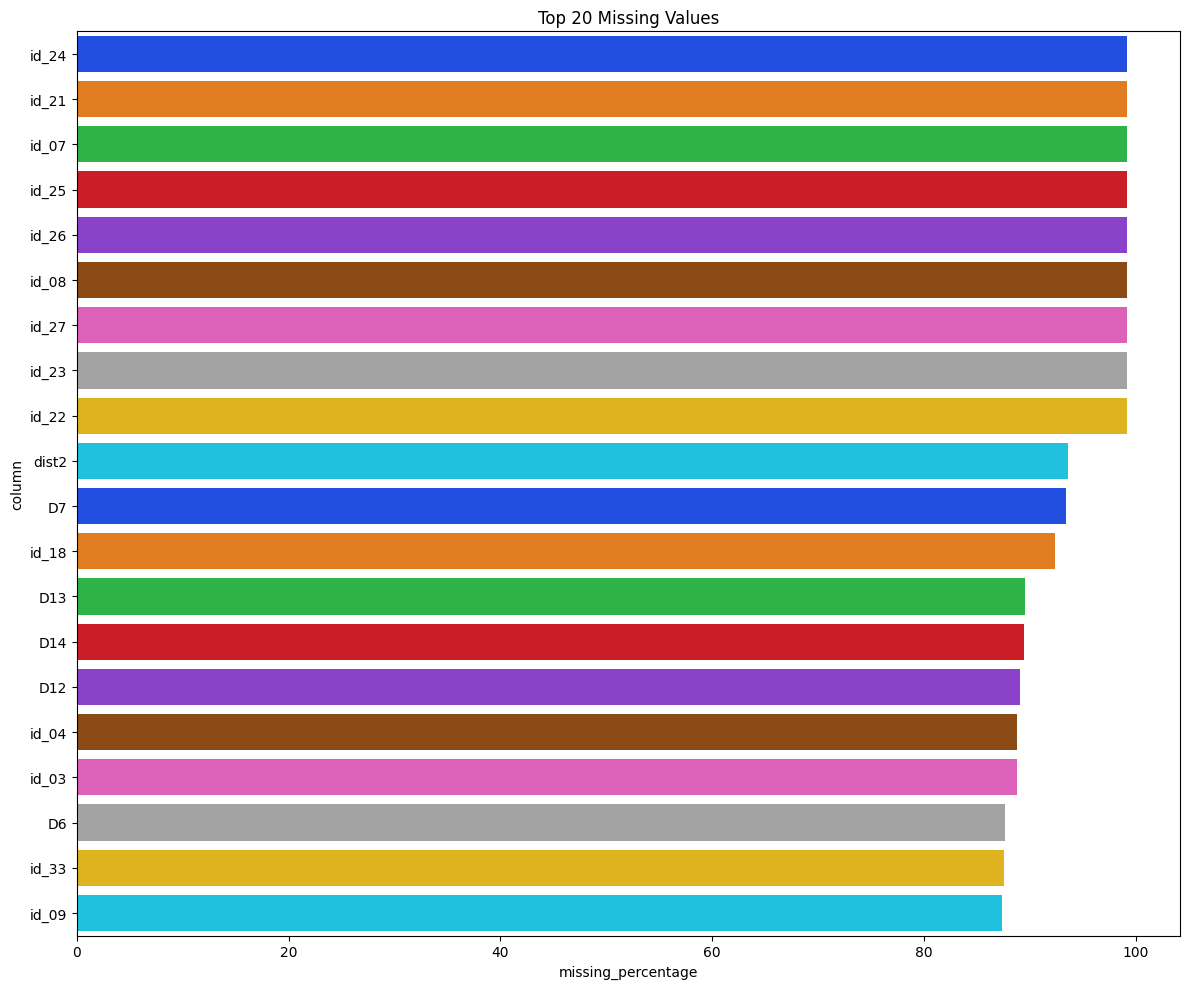

In [ ]:
# Missing value analysis
missing_stats = pd.DataFrame({
    'column': df.columns,
    'missing_count': df.isnull().sum(),
    'missing_percentage': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values(by='missing_percentage', ascending=False)

missing_stats = missing_stats[missing_stats['missing_count'] > 0]

print(f'Features with missing values: {missing_stats.shape[0]}')
print(f'\n =========TOP 20 FEATURES WITH MISSING DATA=========')
print(f'\n{missing_stats.head(20)}')
print()

plt.figure(figsize = (12,10))
sns.barplot(data = missing_stats.head(20), x = 'missing_percentage', y = 'column', palette='bright')
plt.title('Top 20 Missing Values')
plt.tight_layout()
plt.show()

In [ ]:
df.isnull().sum()

,0
TransactionID,0
isFraud,0
TransactionDT,0
TransactionAmt,0
ProductCD,0
...,...
id_36,449555
id_37,449555
id_38,449555
DeviceType,449730


# **Data Cleaning**

In [ ]:
# Handling missing values Plans:
# 1) We can drop features with >90% missing - Not so useful fo ML models
# 2) For categorical: fill with unknown
# 3) For numerical: fill with -999 (because missing values in this project are treated as fraud patterns instead of missing so if we fill
# them with mean/median then model may not know the frauds and treat them as normal which is bad so just keep -999 which is also for our tree
# based models later when we train the data)

# Droping high missing columns
high_missing_cols = missing_stats[missing_stats['missing_percentage'] > 90]['column'].tolist()
df_clean = df.drop(columns = high_missing_cols)

# Separating Categorical and numerical
cat_cols = df_clean.select_dtypes(include = 'object').columns.tolist()
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

# Removing target from num_cols
if 'isFraud' in num_cols:
  num_cols.remove('isFraud')

if 'TransactionID' in num_cols:
  num_cols.remove('TransactionID')

print(f'Catgorical Columns: {len(cat_cols)}')
print(f'Numerical Columns: {len(num_cols)}')

# Filling missing values

for col in cat_cols:
  df_clean[col].fillna('Unknown', inplace = True)

for col in num_cols:
  df_clean[col].fillna(-999, inplace = True)

print(f'\nMissing Values after cleaning: {df_clean.isnull().sum()}')
print(f'\nShape after cleaning: {df_clean.shape}')

Catgorical Columns: 29
Numerical Columns: 391

Missing Values after cleaning: TransactionID     0
isFraud           0
TransactionDT     0
TransactionAmt    0
ProductCD         0
                 ..
id_36             0
id_37             0
id_38             0
DeviceType        0
DeviceInfo        0
Length: 422, dtype: int64

Shape after cleaning: (590540, 422)


# **Feature Engineering**

- Transaction_hour
- Transaction_day
- Transaction_day_of_week
- is_business_hours
- is_weekend
- is_night


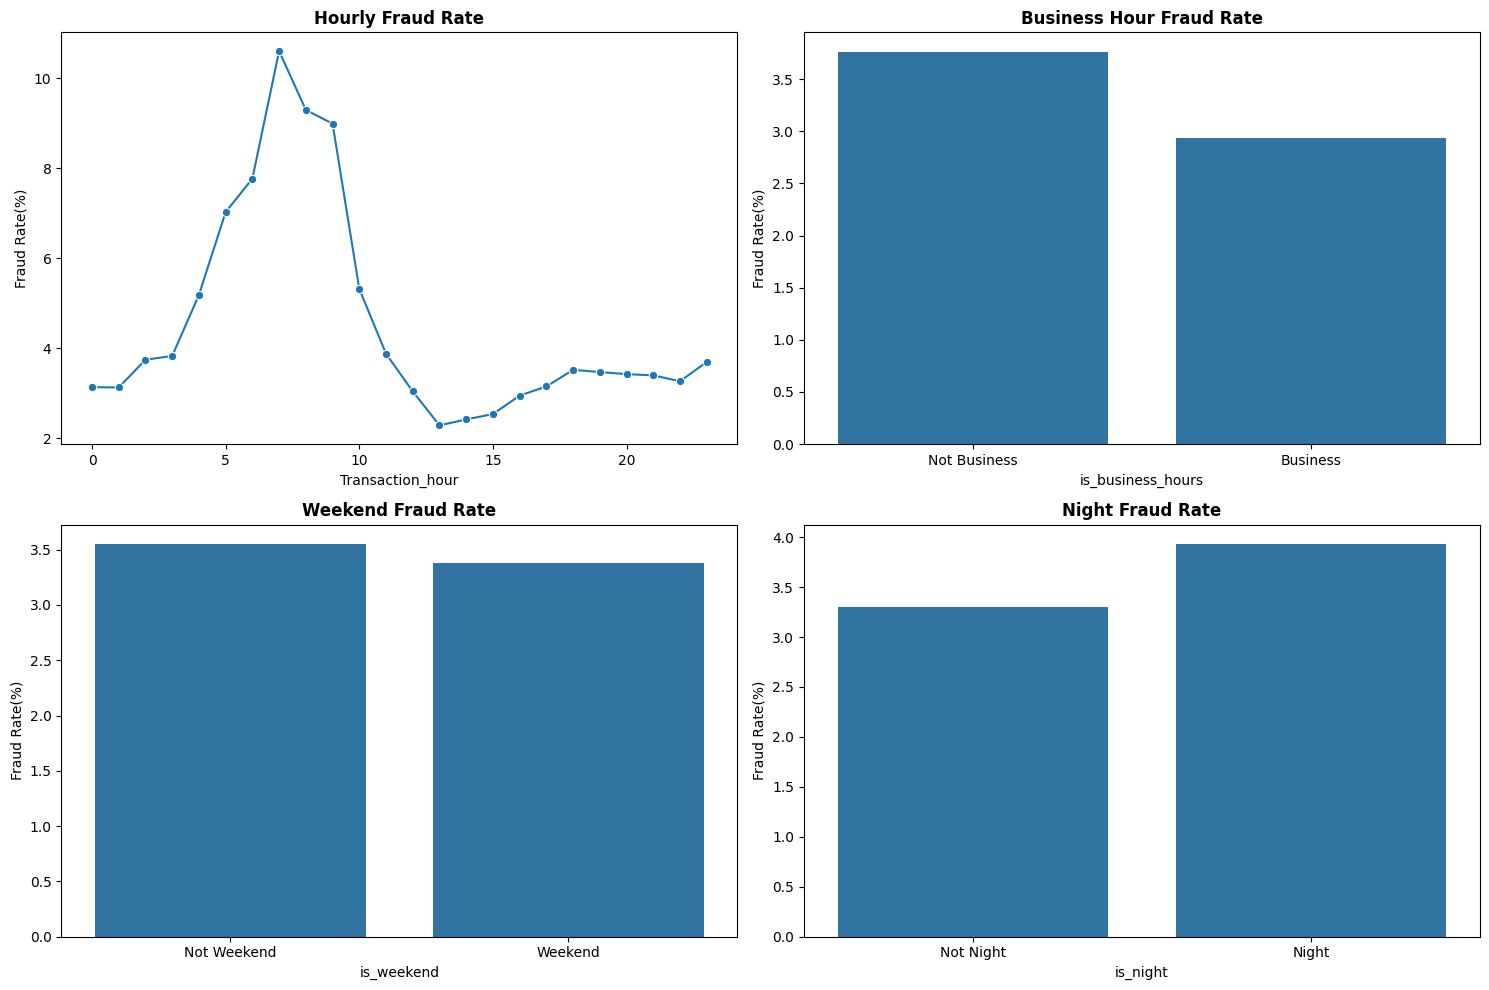

In [ ]:
# Creating Time based Features - (TransactionDT- Right now it's in seconds)

df_clean['Transaction_hour'] = (df_clean['TransactionDT'] // 3600) % 24
df_clean['Transaction_day'] = (df_clean['TransactionDT'] // (3600 * 24))
df_clean['Transaction_day_of_week'] = df_clean['Transaction_day'] % 7

# Business hours indicator(9 am - 5 pm)
df_clean['is_business_hours'] = ((df_clean['Transaction_hour'] >= 9) & (df_clean['Transaction_hour'] <= 17)).astype(int)

# Weekend time
df_clean['is_weekend'] = (df_clean['Transaction_day_of_week'].isin([5,6])).astype(int)

# Night time (11 PM - 6 AM)
df_clean['is_night'] = ((df_clean['Transaction_hour'] >= 23) | (df_clean['Transaction_hour'] <= 6)).astype(int)

time_features = ['Transaction_hour','Transaction_day','Transaction_day_of_week','is_business_hours','is_weekend','is_night']

for features in time_features:
  print(f'- {features}')


# Now let's visualize these things
fig, axes = plt.subplots(2, 2, figsize = (15, 10))
axes = axes.flatten()

# Hourly Fraud Rate
hourly_fraud = df_clean.groupby('Transaction_hour')['isFraud'].mean() * 100
sns.lineplot(x = hourly_fraud.index, y = hourly_fraud.values, marker = 'o', ax = axes[0])
axes[0].set_title('Hourly Fraud Rate', fontweight = 'bold')
axes[0].set_ylabel('Fraud Rate(%)')

# Business Hour
bh_fraud = df_clean.groupby('is_business_hours')['isFraud'].mean() * 100
sns.barplot(x = bh_fraud.index, y = bh_fraud.values, ax = axes[1])
axes[1].set_title('Business Hour Fraud Rate', fontweight = 'bold')
axes[1].set_ylabel('Fraud Rate(%)')
axes[1].set_xticklabels(['Not Business', 'Business'])

# Weekend
weekend_fraud = df_clean.groupby('is_weekend')['isFraud'].mean() * 100
sns.barplot(x = weekend_fraud.index, y = weekend_fraud.values, ax = axes[2])
axes[2].set_title('Weekend Fraud Rate', fontweight = 'bold')
axes[2].set_xticklabels(['Not Weekend', 'Weekend'])
axes[2].set_ylabel('Fraud Rate(%)')

# Night time
night_fraud = df_clean.groupby('is_night')['isFraud'].mean() * 100
sns.barplot(x = night_fraud.index, y = night_fraud.values, ax = axes[3])
axes[3].set_title('Night Fraud Rate', fontweight = 'bold')
axes[3].set_xticklabels(['Not Night', 'Night'])
axes[3].set_ylabel('Fraud Rate(%)')

plt.tight_layout()
plt.show()

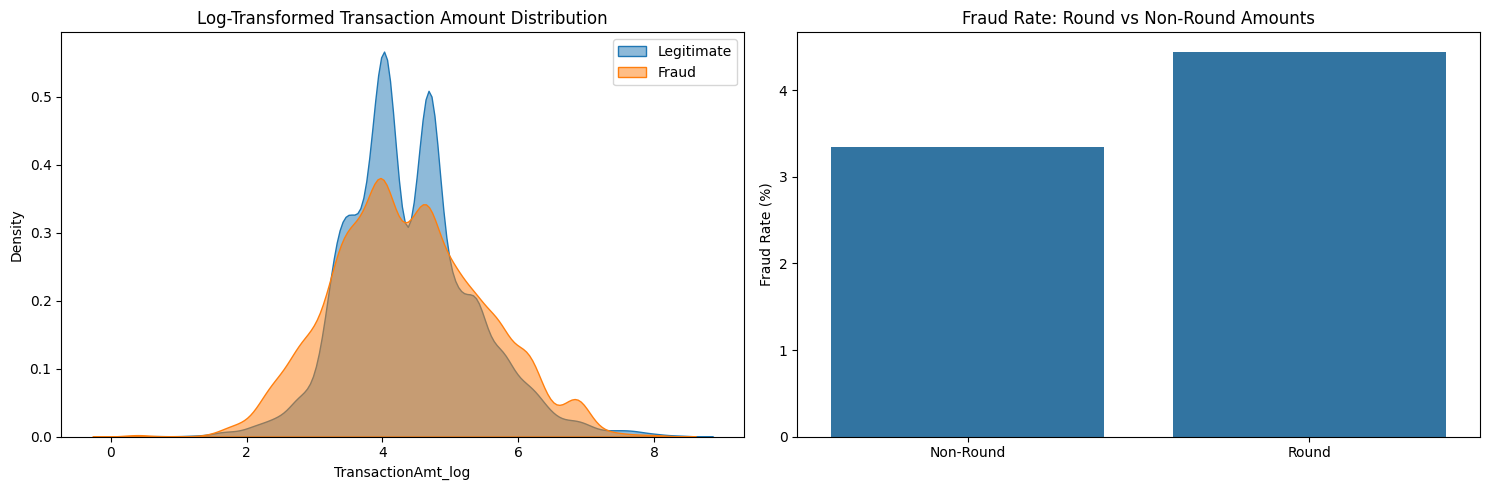

In [ ]:
# Creating Transaction based feature engineering

df_clean['TransactionAmt_log'] = np.log1p(df_clean['TransactionAmt']) # To handle skewness --> We use log

# Decimal part --> Because there might be pattern in cents
df_clean['TransactionAmt_decimal'] = df_clean['TransactionAmt'] - df_clean['TransactionAmt'].astype(int)

df_clean['Transaction_bins'] = pd.cut(
    df_clean['TransactionAmt'],
    bins = [0,50,100,200,500,float('inf')],
    labels = ['very_low','low','medium','high','very_high']
)

# Round amounts
df_clean['is_round_amount'] = (df_clean['TransactionAmt'] % 10 == 0).astype(int)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Log transformation
sns.kdeplot(data=df_clean[df_clean['isFraud']==0].sample(10000),
            x='TransactionAmt_log', label='Legitimate', ax=axes[0], fill=True, alpha=0.5)
sns.kdeplot(data=df_clean[df_clean['isFraud']==1].sample(10000),
            x='TransactionAmt_log', label='Fraud', ax=axes[0], fill=True, alpha=0.5)
axes[0].set_title('Log-Transformed Transaction Amount Distribution')
axes[0].legend()

# Round amounts
round_fraud = df_clean.groupby('is_round_amount')['isFraud'].mean() * 100
sns.barplot(x=[0, 1], y=round_fraud.values, ax=axes[1])
axes[1].set_title('Fraud Rate: Round vs Non-Round Amounts')
axes[1].set_xticklabels(['Non-Round', 'Round'])
axes[1].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.show()

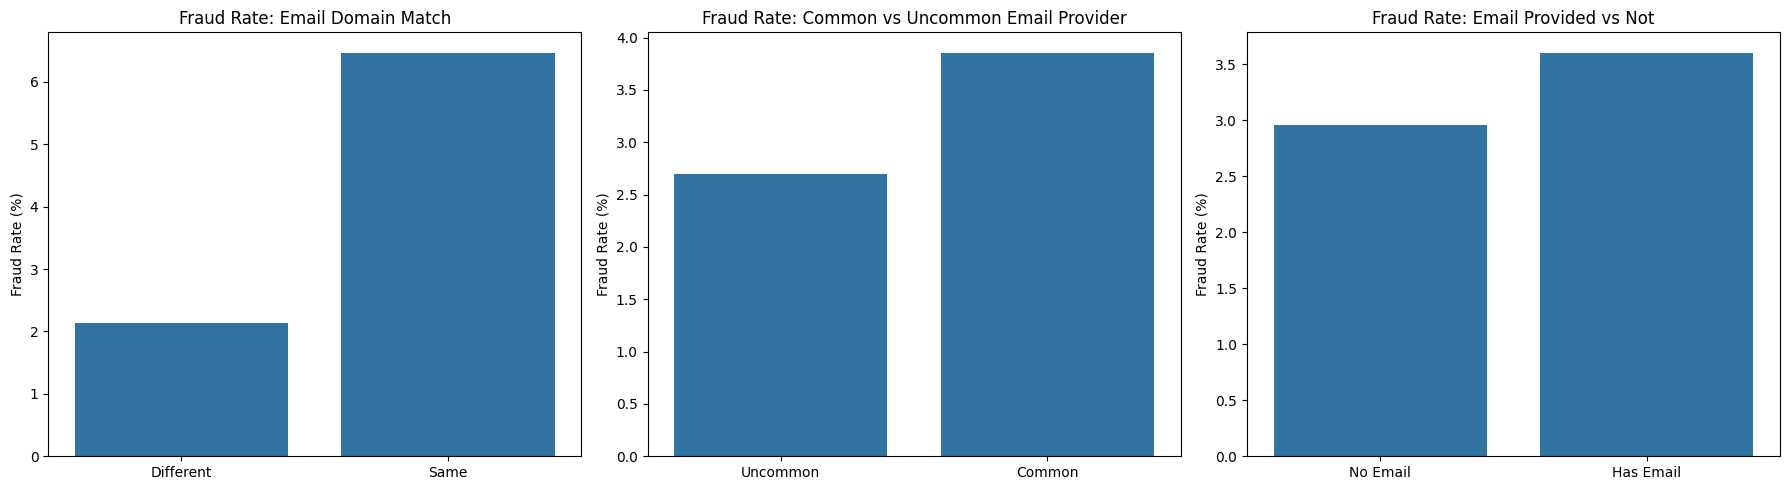

In [ ]:
# Email Domain Feature Engineering

# Email domain match
df_clean['email_domain_match'] = (df_clean['P_emaildomain'] == df_clean['R_emaildomain']).astype(int)

# Common emails - Mostly used
common_providers = ['gmail.com','yahoo.com','hotmail.com','outlook.com','aol.com']
df_clean['P_email_is_common'] = df_clean['P_emaildomain'].isin(common_providers).astype(int)
df_clean['R_email_is_common'] = df_clean['R_emaildomain'].isin(common_providers).astype(int)

# Email domain exits
df_clean['has_P_email'] = (df_clean['P_emaildomain'] != 'Unknown').astype(int)
df_clean['has_R_email'] = (df_clean['R_emaildomain'] != 'Unknown').astype(int)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Email match
match_fraud = df_clean.groupby('email_domain_match')['isFraud'].mean() * 100
sns.barplot(x=[0, 1], y=match_fraud.values, ax=axes[0])
axes[0].set_title('Fraud Rate: Email Domain Match')
axes[0].set_xticklabels(['Different', 'Same'])
axes[0].set_ylabel('Fraud Rate (%)')

# Common provider
common_fraud = df_clean.groupby('P_email_is_common')['isFraud'].mean() * 100
sns.barplot(x=[0, 1], y=common_fraud.values, ax=axes[1])
axes[1].set_title('Fraud Rate: Common vs Uncommon Email Provider')
axes[1].set_xticklabels(['Uncommon', 'Common'])
axes[1].set_ylabel('Fraud Rate (%)')

# Has email
has_email_fraud = df_clean.groupby('has_P_email')['isFraud'].mean() * 100
sns.barplot(x=[0, 1], y=has_email_fraud.values, ax=axes[2])
axes[2].set_title('Fraud Rate: Email Provided vs Not')
axes[2].set_xticklabels(['No Email', 'Has Email'])
axes[2].set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.show()

# **Encoding**

In [ ]:
df_clean.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,is_night,TransactionAmt_log,TransactionAmt_decimal,Transaction_bins,is_round_amount,email_domain_match,P_email_is_common,R_email_is_common,has_P_email,has_R_email
0,2987000,0,86400,68.5,W,13926,-999.0,150.0,discover,142.0,...,1,4.241327,0.5,low,0,1,0,0,0,0
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,1,3.401197,0.0,very_low,0,0,1,0,1,0
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,1,4.094345,0.0,low,0,0,1,0,1,0
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,1,3.931826,0.0,very_low,1,0,1,0,1,0
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,1,3.931826,0.0,very_low,1,0,1,0,1,0


In [ ]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder

cat_features = df_clean.select_dtypes(include = ['object']).columns.tolist()
cat_features.append('Transaction_bins')

if 'TransactionID' in cat_features:
  cat_features.remove('TransactionID')

print(f'Categorical Features to encode: {len(cat_features)}')

label_dict = {}
for col in cat_features:
  label = LabelEncoder()
  df_clean[col] = label.fit_transform(df_clean[col])
  label_dict[col] = label

Categorical Features to encode: 30


In [ ]:
df_clean.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,is_night,TransactionAmt_log,TransactionAmt_decimal,Transaction_bins,is_round_amount,email_domain_match,P_email_is_common,R_email_is_common,has_P_email,has_R_email
0,2987000,0,86400,68.5,4,13926,-999.0,150.0,2,142.0,...,1,4.241327,0.5,1,0,1,0,0,0,0
1,2987001,0,86401,29.0,4,2755,404.0,150.0,3,102.0,...,1,3.401197,0.0,4,0,0,1,0,1,0
2,2987002,0,86469,59.0,4,4663,490.0,150.0,4,166.0,...,1,4.094345,0.0,1,0,0,1,0,1,0
3,2987003,0,86499,50.0,4,18132,567.0,150.0,3,117.0,...,1,3.931826,0.0,4,1,0,1,0,1,0
4,2987004,0,86506,50.0,1,4497,514.0,150.0,3,102.0,...,1,3.931826,0.0,4,1,0,1,0,1,0


# **Train Test Split**

In [ ]:
# For this project(Fraud Detection)--> We will do Time based split instead of random because we want to predict future fraud
# using past data

# Sort by time
df_clean = df_clean.sort_values(by = 'TransactionDT').reset_index(drop = True)

# Split first 80% for training and last 20% for testing
split_index = int(len(df_clean) * 0.8)

train_df = df_clean[:split_index].copy()
test_df = df_clean[split_index:].copy()

print(f'Training set: {train_df.shape}')
print(f'  - Fraud Rate: {train_df['isFraud'].mean() * 100:.2f}%')
print(f'\nTesting set: {test_df.shape}')
print(f'  - Fraud Rate: {test_df['isFraud'].mean() * 100:.2f}%')

# Preparing X and Y
features_to_drop = ['TransactionID','TransactionDT','isFraud']
X_train = train_df.drop(columns=features_to_drop, errors = 'ignore')
y_train = train_df['isFraud']

X_test = test_df.drop(columns=features_to_drop, errors = 'ignore')
y_test = test_df['isFraud']

print(f'\nX_train shape: {X_train.shape}')
print(f'X_test Shape: {X_test.shape}')
print(f'Total features: {X_train.shape[1]}')

Training set: (472432, 437)
  - Fraud Rate: 3.51%

Testing set: (118108, 437)
  - Fraud Rate: 3.44%

X_train shape: (472432, 434)
X_test Shape: (118108, 434)
Total features: 434


In [ ]:
# Saving full cleaned Data
df_clean.to_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Processed Data/df_clean.csv', index = False)

# Saving train/test splits
train_df.to_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Processed Data/train_df.csv', index = False)
test_df.to_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Processed Data/test_df.csv', index = False)

# Saving X and y - train and test
X_train.to_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Processed Data/X_train.csv', index = False)
y_train.to_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Processed Data/y_train.csv', index = False)

X_test.to_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Processed Data/X_test.csv', index = False)
y_test.to_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Processed Data/y_test.csv', index = False)

# Saving Feature names
feature_names = X_train.columns.tolist()
pd.DataFrame({'feature': feature_names}).to_csv('/content/drive/MyDrive/Colab_Notebooks/Fraud_Detection_System_Project/2) Data/Processed Data/feature_names.csv', index = False)

print('All processed data saved.')

All processed data saved.


# **Summary**

## Data Cleaning
- Started with 434 features
- Dropped features with >90% missing values
- Handled remaining missing values:
  - Categorical: filled with 'unknown'
  - Numerical: filled with -999
  
## Feature Engineering
Created **15 new features** across 4 categories:

### 1. Time Features (6)
- Transaction_hour, Transaction_day, Transaction_day_of_week
- is_business_hours, is_weekend, is_night

### 2. Amount Features (4)
- TransactionAmt_log (reduces skewness)
- TransactionAmt_decimal (cents pattern)
- TransactionAmt_bin (categorical bins)
- is_round_amount (fraud indicator)

### 3. Email Features (5)
- email_domain_match
- P_email_is_common, R_email_is_common
- has_P_email, has_R_email

### 4. Encoding
- Label encoded all categorical variables

## Train-Test Split
- Time-based split (80/20)
- Training: 472,432 transactions
- Testing: 118,108 transactions
- Preserves temporal order (realistic evaluation)

